# Cardiac Pathology Prediction (IMA205 Challenge 2025)
## Mariana OLM REZENDE

### Index
[1. Introduction](#introduction)  
[2. Importing packages and data](#importing-packages-and-data)  
[3. Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)  
[4. Missing Segmentation (LV)](#lv-segmentation)  
[5. Metrics and Features](#metrics-and-features)  
[6. Model](#model)  
[7. Conclusion](#conclusion)

# 1. Introduction <a name="introduction"></a>

The goal of the challenge is to classify subjects based on their CMRI exams among five different diagnostic classes:

0. Healthy controls
1. Myocardial infarction
2. Dilated cardiomyopathy
3. Hypertrophic cardiomyopathy
4. Abnormal right ventricle

# 2. Importing packages, functions and data <a name="importing-packages-and-data"></a>

## Packages

In [20]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


import os
import nibabel as nib

from scipy.ndimage import binary_fill_holes
from skimage.morphology import convex_hull_image, label
from skimage.measure import label, regionprops

## Functions

In [21]:
def data_to_dict(path):
    """
    Loads ED, ES, and their segmentations for each subject folder inside path.

    Returns:
        data_dict: A dictionary of the form:
            data_dict[subject_name] = {
                'ED': nib.Nifti1Image,
                'ES': nib.Nifti1Image,
                'ED_seg': nib.Nifti1Image,
                'ES_seg': nib.Nifti1Image
            }
    """
    
    data_dict = {}

    for subject_folder in os.listdir(path):
        subject_path = os.path.join(path, subject_folder)
        
        if os.path.isdir(subject_path):
            ed_path     = os.path.join(subject_path, f"{subject_folder}_ED.nii")
            es_path     = os.path.join(subject_path, f"{subject_folder}_ES.nii")
            ed_seg_path = os.path.join(subject_path, f"{subject_folder}_ED_seg.nii")
            es_seg_path = os.path.join(subject_path, f"{subject_folder}_ES_seg.nii")
            
            if all(os.path.isfile(path) for path in [ed_path, es_path, ed_seg_path, es_seg_path]):
                ed_img     = nib.load(ed_path)
                es_img     = nib.load(es_path)
                ed_seg_img = nib.load(ed_seg_path)
                es_seg_img = nib.load(es_seg_path)

                data_dict[subject_folder] = {
                    'ED': ed_img,
                    'ES': es_img,
                    'ED_seg': ed_seg_img,
                    'ES_seg': es_seg_img
                }

    return data_dict

def get_volumetric_image(subject_data):

    ed_img = subject_data['ED'].get_fdata()
    es_img = subject_data['ES'].get_fdata()
    ed_seg = subject_data['ED_seg'].get_fdata()
    es_seg = subject_data['ES_seg'].get_fdata()

    return ed_img, es_img, ed_seg, es_seg

def get_header(subject_data):

    ed_header = subject_data['ED'].header
    es_header = subject_data['ES'].header
    ed_seg_header = subject_data['ED_seg'].header
    es_seg_header = subject_data['ES_seg'].header

    return ed_header, es_header, ed_seg_header, es_seg_header

def compute_iou(pred, true, label):
    """
    Compute IoU for a given label.
    Returns a tuple (dice, iou).
    """
    
    pred_mask = (pred == label)
    true_mask = (true == label)
    
    intersection = np.sum(pred_mask & true_mask)
    union = np.sum(pred_mask | true_mask)
    
    iou = intersection / union if union > 0 else 1.0

    #iou = intersection / union

    return iou

def fill_lv_inside_myo(seg_3d, myo_label=2, lv_label=3):
    """
    Fills the inside of the myocardium (myo_label) with the LV label (lv_label) 
    on slices.

    Parameters:
        seg_3d (ndarray): 3D segmentation volume.
        myo_label (int): Label for myocardium.
        lv_label (int): Label for left ventricle.

    Returns:
        ndarray: Modified 3D segmentation with filled LV inside myocardium.
    """
    seg_filled = seg_3d.copy()
    seg_filled[seg_filled==3] = 0 # background
    
    # Process each slice independently
    for z in range(seg_filled.shape[-1]):
        slice_data = seg_filled[:,:, z]
        
        # Only process slices that contain any Myocardium
        if np.any(slice_data == myo_label):
            myo_mask = (slice_data == myo_label)

            # Fill enclosed holes in myocardium
            filled_myo = binary_fill_holes(myo_mask)

            # Identify filled-in regions and assign LV label to these regions
            new_lv_area = filled_myo & ~myo_mask 
                
            slice_data[new_lv_area] = lv_label         
            seg_filled[..., z] = slice_data     

    return seg_filled


def solution_lv_inside_myo(seg_3d, myo_label=2, lv_label=3):
    """
    Fills the inside of the myocardium (myo_label) with the LV label (lv_label) 
    on slices.

    Parameters:
        seg_3d (ndarray): 3D segmentation volume.
        myo_label (int): Label for myocardium.
        lv_label (int): Label for left ventricle.

    Returns:
        ndarray: Modified 3D segmentation with filled LV inside myocardium.
    """
    seg_filled = seg_3d.copy()
    seg_filled[seg_filled==lv_label] = 0  # Reset any LV label to background
    
    # Process each slice independently
    for z in range(seg_filled.shape[-1]):
        slice_data = seg_filled[:, :, z]
        
        # Only process slices that contain any Myocardium
        if np.any(slice_data == myo_label):
            myo_mask = (slice_data == myo_label)

            # Use convex hull on the myocardium
            convex_myo = convex_hull_image(myo_mask)

            # Identify filled-in regions inside myocardium
            new_lv_area = convex_myo & ~myo_mask 

            # Keep only the largest connected component in new_lv_area
            labeled_area = label(new_lv_area)
            
            if labeled_area.max() > 0:
                regions = regionprops(labeled_area)
                largest_region = max(regions, key=lambda r: r.area)
                largest_mask = (labeled_area == largest_region.label)
            else:
                largest_mask = new_lv_area

            slice_data[largest_mask] = lv_label
            seg_filled[:, :, z] = slice_data

    return seg_filled

## Data

In [3]:
path_data = 'Dataset/'
path_train = path_data + 'Train'
path_test = path_data + 'Test'

### MetaData

In [4]:
df_metadata_train = pd.read_csv(path_data + 'metaDataTrain.csv')
df_metadata_test = pd.read_csv(path_data + 'metaDataTest.csv')

### NIfTI Data

In [5]:
nifti_train_dict = data_to_dict(path_train)
list_keys_train = list(nifti_train_dict.keys())

nifti_test_dict = data_to_dict(path_test)
list_keys_test = list(nifti_test_dict.keys())

# 3. Exploratory Data Analysis (EDA) <a name="exploratory-data-analysis-eda"></a>


## MetaData

In [6]:
df_metadata_train.head()

,Id,Category,Height,Weight
0,1,2,184.0,95.0
1,2,2,160.0,70.0
2,3,2,165.0,77.0
3,4,2,159.0,46.0
4,5,2,165.0,77.0


In [7]:
pd.DataFrame(df_metadata_train['Category'].sort_values(ascending=True).value_counts())

,count
Category,
0,20
1,20
2,20
3,20
4,20


**Boxplot:** Height and Weight by Diagnostic Classes

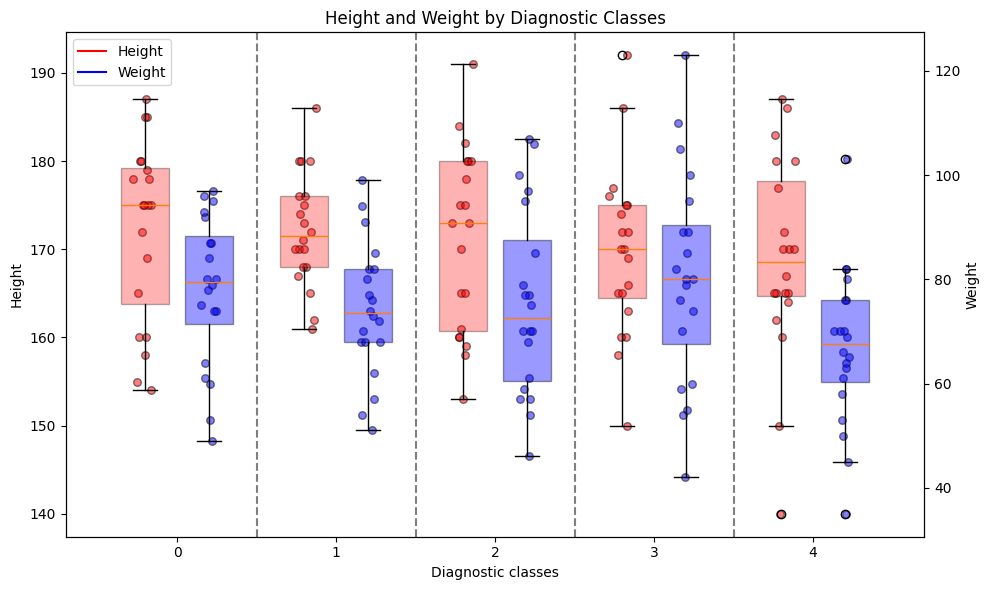

In [8]:
cats = sorted(df_metadata_train['Category'].unique())
xvals = np.arange(len(cats))

height_data = [df_metadata_train.loc[df_metadata_train['Category'] == c, 'Height'].values for c in cats]
weight_data = [df_metadata_train.loc[df_metadata_train['Category'] == c, 'Weight'].values for c in cats]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
offset = 0.2

bp1 = ax1.boxplot(
    height_data,
    positions=xvals - offset,
    widths=0.3,
    patch_artist=True)

for patch in bp1['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.3)

for i, cat_heights in enumerate(height_data):
    x_jitter = np.random.normal(loc=xvals[i] - offset, scale=0.03, size=len(cat_heights))
    ax1.scatter(x_jitter, cat_heights, color='red', edgecolors='k', alpha=0.5, s=30)

bp2 = ax2.boxplot(
    weight_data,
    positions=xvals + offset,
    widths=0.3,
    patch_artist=True)

for patch in bp2['boxes']:
    patch.set_facecolor('blue')
    patch.set_alpha(0.4)

for i, cat_weights in enumerate(weight_data):
    x_jitter = np.random.normal(loc=xvals[i] + offset, scale=0.03, size=len(cat_weights))
    ax2.scatter(x_jitter, cat_weights, color='blue', edgecolors='k', alpha=0.5, s=30)

ax1.set_xticks(xvals)
ax1.set_xticklabels(cats)
for boundary in xvals[1:]:
    ax1.axvline(boundary - 0.5, color='k', linestyle='--', alpha=0.5)

ax1.set_xlabel('Diagnostic classes')
ax1.set_ylabel('Height')
ax2.set_ylabel('Weight')
ax1.set_title('Height and Weight by Diagnostic Classes')
ax1.plot([], c='red', label='Height')
ax1.plot([], c='blue', label='Weight')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

## NIfTI Data

Each <nibabel.nifti1.Nifti1Image> object essentially wraps:
* **Volumetric Image Data** (the raw voxel intensities) – typically a NumPy array of shape (X, Y, Z), or (X, Y, Z, Time).
* **Affine** (a 4×4 transformation matrix) – mapping voxel indices to real-world (scanner) coordinates.
* **Header/Metadata** – including voxel dimensions (spacing), data type, acquisition parameters, etc.

### Volumetric Image Data

For each subject, **two images** are provided at two different time points along the cardiac cycle: one image at end **diastole** (end of dilation) and one image at end **systole** (end of contraction) and also their segmentations:
* ED.nii is the end diastole volume
* ES.nii is the end systole volume
* ED_seg.nii is the end diastole segmentation
* ES_seg.nii is the end systole segmentation


Each **segmentation map** consists in a 3D multi-label mask, where each label stands for the following structures:
* 0 - Background
* 1 - Right ventricle cavity (Red)
* 2 - Myocardium (Green)
* 3 - Left ventricle cavity (Blue)



#### Visualizing the data

In [9]:
random_index = random.choice(list_keys_train)

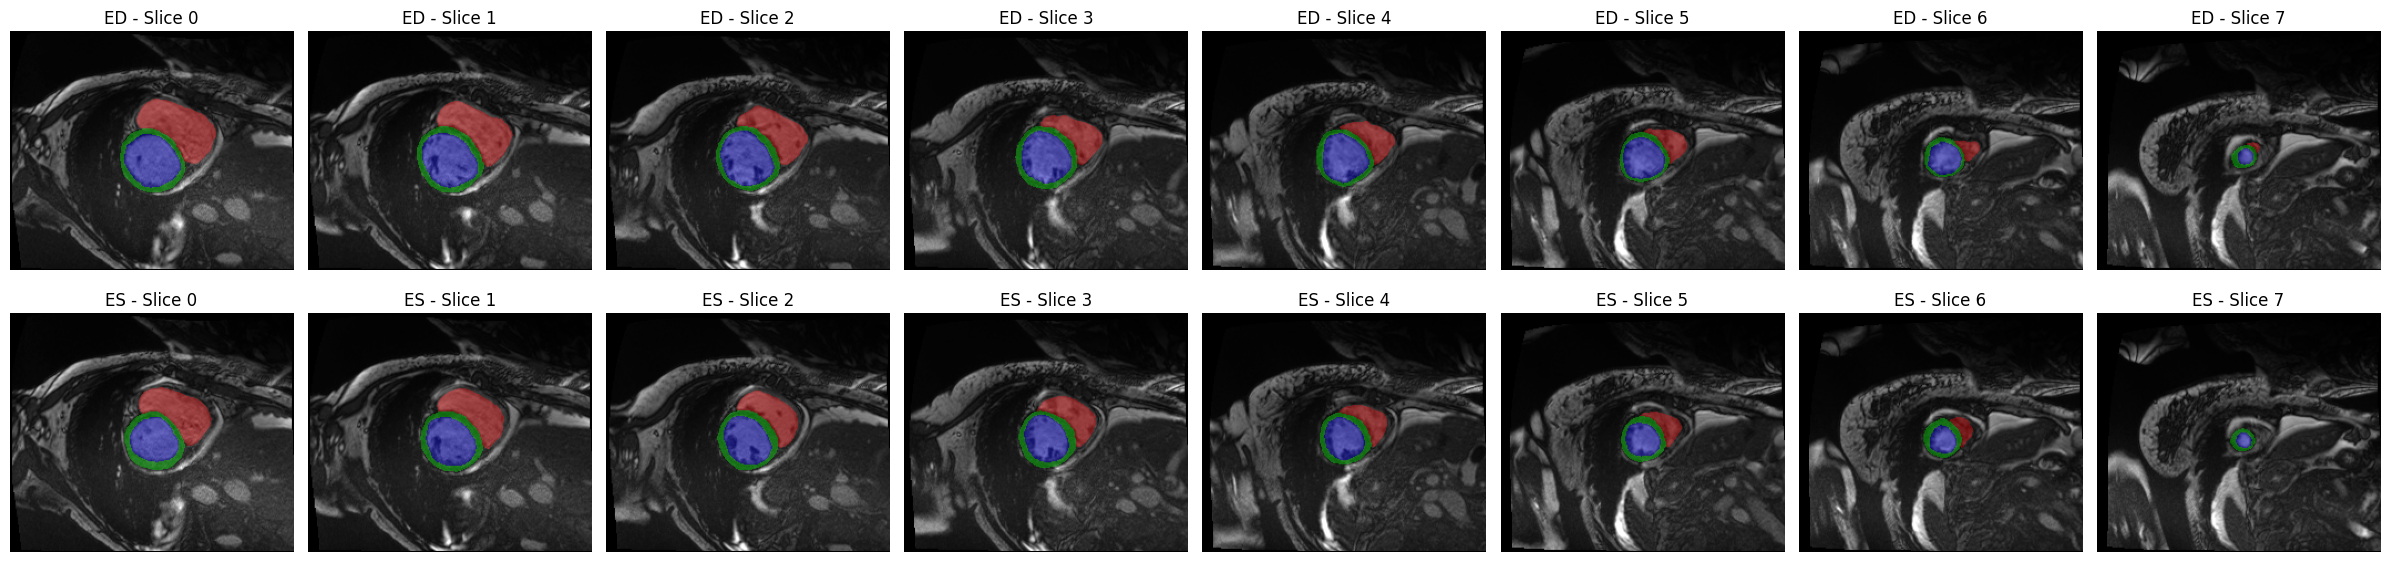

In [10]:
subject_data = nifti_train_dict[random_index]
ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)


label_cmap = mcolors.ListedColormap([
    (0.0, 0.0, 0.0, 0.0),
    (1.0, 0.0, 0.0, 0.6),
    (0.0, 1.0, 0.0, 0.6), 
    (0.0, 0.0, 1.0, 0.6) 
])


n_slices = ed_img.shape[-1]
fig, axes = plt.subplots(nrows=2, ncols=n_slices, figsize=(3*n_slices, 6))

for i in range(n_slices):
    # ED 
    axes[0, i].imshow(ed_img[:, :, i], cmap='gray', alpha=1.0)
    axes[0, i].imshow(ed_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[0, i].set_title(f"ED - Slice {i}")
    axes[0, i].axis('off')

    # ES 
    axes[1, i].imshow(es_img[:, :, i], cmap='gray', alpha=1.0)
    axes[1, i].imshow(es_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[1, i].set_title(f"ES - Slice {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

#### **Histogram:** Number of slices

All subjects have matching slice counts for ED, ES, and segmentations.



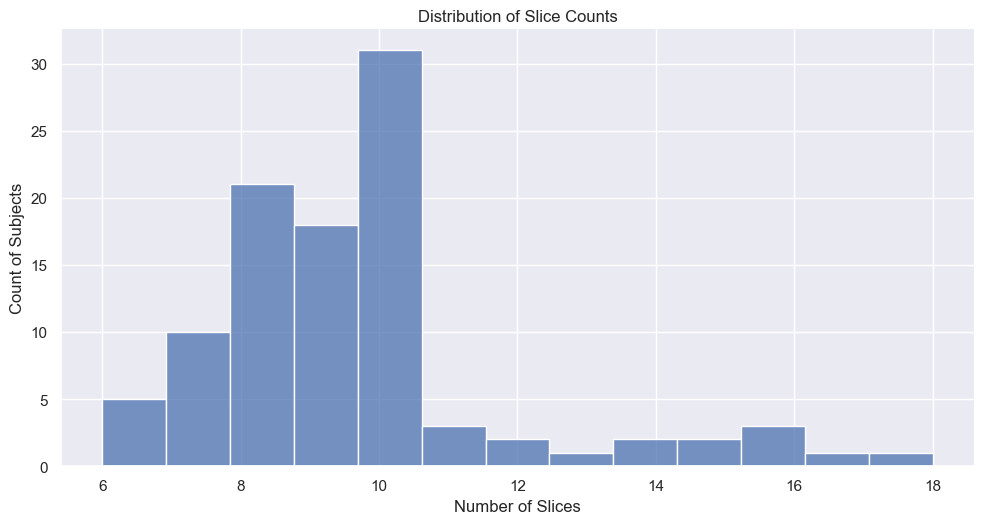

In [11]:
number_slices = []
mismatched_subjects = []

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    n_slices = ed_img.shape[-1]
    number_slices.append(n_slices)

    if not (ed_img.shape[-1] == es_img.shape[-1] == ed_seg.shape[-1] == es_seg.shape[-1]):
        mismatched_subjects.append(subj_id)

if mismatched_subjects:
    print("Subjects with inconsistent shapes:", mismatched_subjects)
else:
    print("All subjects have matching slice counts for ED, ES, and segmentations.\n")

sns.set();
sns.displot(number_slices, bins=len(np.unique(number_slices)), aspect=2);
plt.xlabel("Number of Slices")
plt.ylabel("Count of Subjects")
plt.title("Distribution of Slice Counts")
plt.show()

#### Number of segmentated structures
Dataframe showing how many volumes contain each labeled structure (Background, Right ventricle cavity, Myocardium, Left ventricle cavity) in the ED and ES phases for both training and testing data.

In [12]:
train_ed_layer_counts = np.zeros(4, dtype=int)
train_es_layer_counts = np.zeros(4, dtype=int)
test_ed_layer_counts  = np.zeros(4, dtype=int)
test_es_layer_counts  = np.zeros(4, dtype=int)

dict_layers = {
    '0': 'Background',
    '1': 'Right ventricle cavity',
    '2': 'Myocardium',
    '3': 'Left ventricle cavity'
}

labels = [0, 1, 2, 3]
layer_names = [dict_layers[str(l)] for l in labels]

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    # Check presence of each label in ED / ES
    unique_ed = np.unique(ed_seg)
    unique_es = np.unique(es_seg)
    
    for label in labels:
        if label in unique_ed:
            train_ed_layer_counts[label] += 1
        if label in unique_es:
            train_es_layer_counts[label] += 1

for index in list_keys_test:
    subject_data = nifti_test_dict[index]
    ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

    unique_ed = np.unique(ed_seg)
    unique_es = np.unique(es_seg)
    
    for label in labels:
        if label in unique_ed:
            test_ed_layer_counts[label] += 1
        if label in unique_es:
            test_es_layer_counts[label] += 1

data_array = [
    train_ed_layer_counts,
    train_es_layer_counts,
    test_ed_layer_counts,
    test_es_layer_counts
]

row_index = pd.MultiIndex.from_tuples(
    [
        ("Train", "ED"),
        ("Train", "ES"),
        ("Test",  "ED"),
        ("Test",  "ES")
    ],
    names=["Data Split", "Phase"]
)

df_seg_counts = pd.DataFrame(
    data=data_array,
    index=row_index,
    columns=layer_names
)

display(df_seg_counts)

Background  Right ventricle cavity  Myocardium  \
Data Split Phase                                                   
Train      ED            100                     100         100   
           ES            100                     100         100   
Test       ED             50                      50          50   
           ES             50                      50          50   

                  Left ventricle cavity  
Data Split Phase                         
Train      ED                       100  
           ES                       100  
Test       ED                         0  
           ES                         0

Based on the current data, there is **no segmentation** labeled for the **left ventricle** in any of the **test volumes**.

### Affine

### Header
The most important **header fields** for this project will be:
1) [dim] = [3, 208, 174, 10, 1, 1, 1, 1]
   * dim[0]: number of dimensions
   * dim[1], dim[2], dim[3] = number of voxels along the 3 axes
2) [pixdim] = [1., 1.68269, 1.68269, 5., 1., 1., 1., 1.]
   * pixdim[1], pixdim[2], pixdim[3] give the voxel size in millimeters along the 3 axes
   * the method get_zooms() returns [pixdim[1], pixdim[2], pixdim[3]] 

In [13]:
subject_data = nifti_train_dict[random_index]
ed_header, es_header, ed_seg_header, es_seg_header = get_header(subject_data)

In [14]:
voxel_pixdim = []

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    ed_header, es_header, ed_seg_header, es_seg_header = get_header(subject_data)

    # Extracting voxel dimensions
    voxel_pixdims = ed_seg_header.get_zooms()
    voxel_pixdim.append(voxel_pixdims)

# 4. Missing Segmentation (LV) <a name="lv-segmentation"></a>
As previously noted, the test volumes do not include LV segmentations, which must be generated in order to compute certain classification metrics.

#### Example of missing LV segmentation

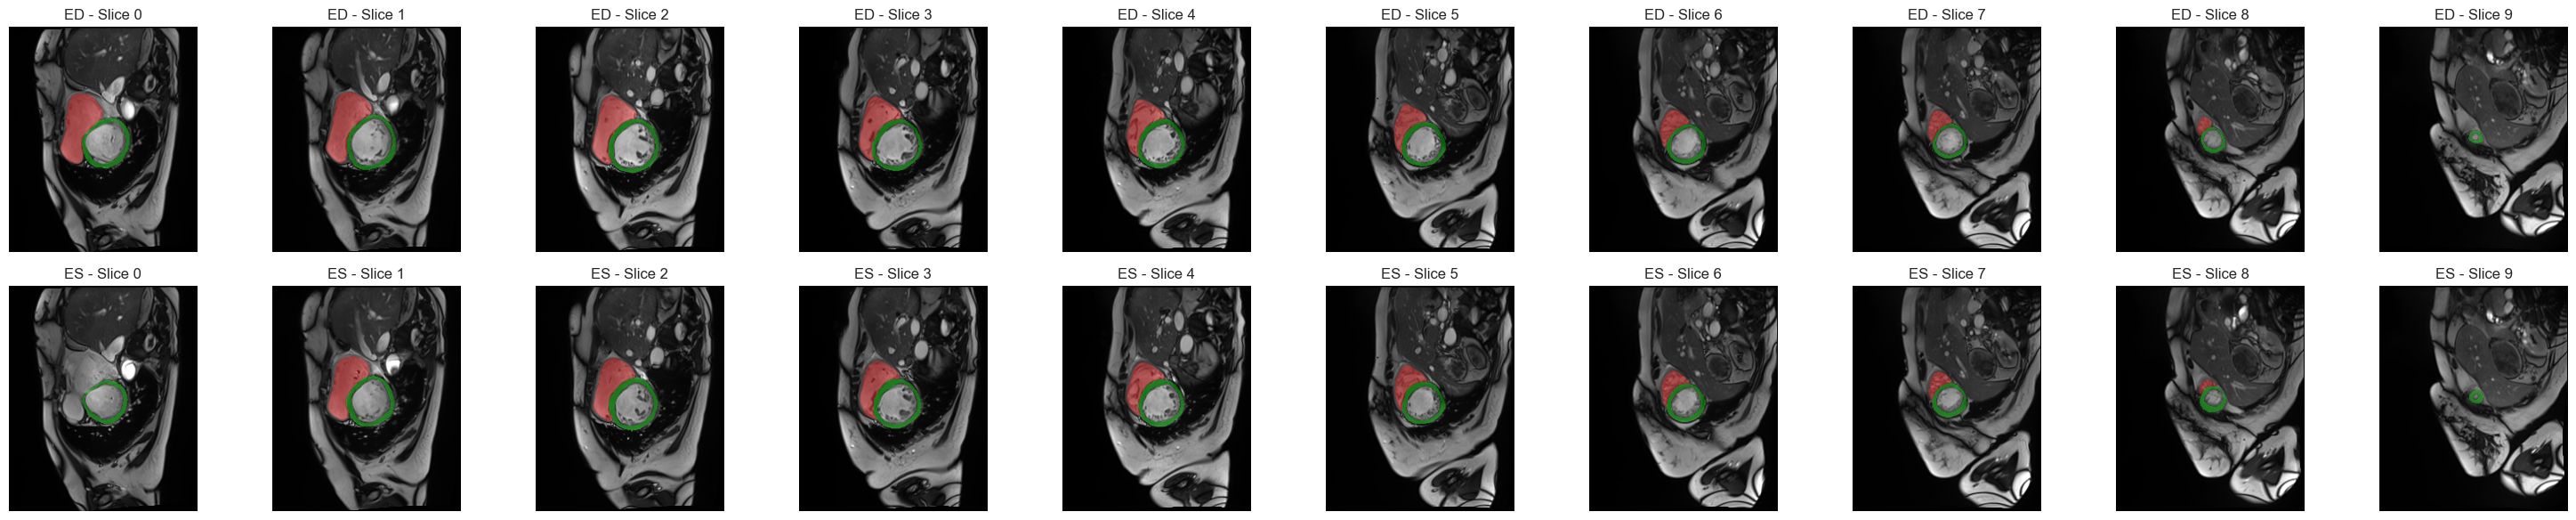

In [15]:
random_index = random.choice(list_keys_test)

subject_data = nifti_test_dict[random_index]
ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

n_slices = ed_img.shape[-1]
fig, axes = plt.subplots(nrows=2, ncols=n_slices, figsize=(3*n_slices, 6))

for i in range(n_slices):
    # ED 
    axes[0, i].imshow(ed_img[:, :, i], cmap='gray', alpha=1.0)
    axes[0, i].imshow(ed_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[0, i].set_title(f"ED - Slice {i}")
    axes[0, i].axis('off')

    # ES 
    axes[1, i].imshow(es_img[:, :, i], cmap='gray', alpha=1.0)
    axes[1, i].imshow(es_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[1, i].set_title(f"ES - Slice {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Hypothesis
A potential assumption is that the region enclosed by the Myocardium (green) corresponds to the Left Ventricle (LV). To evaluate this hypothesis, the Intersection over Union (IoU) will be calculated between the LV region extracted using the proposed method and the ground truth LV layer in the training data.

In [27]:
overall_imperfect = {}  # Dictionary to store imperfect slice details per subject
list_fails = []

threshold = 0.5

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    _, _, ed_seg, es_seg = get_volumetric_image(subject_data)
    
    pred_ed_seg = fill_lv_inside_myo(ed_seg, myo_label=2, lv_label=3)
    pred_es_seg = fill_lv_inside_myo(es_seg, myo_label=2, lv_label=3)
    
    num_slices = ed_seg.shape[-1]
    subject_imperfect = {"ED": [], "ES": []}

    for z in range(num_slices):
        gt_has_lv = np.any(ed_seg[..., z] == 3)
        gt_has_myo = np.any(ed_seg[..., z] == 2)
        
        if gt_has_lv or gt_has_myo:
        
            iou_lv_ed = compute_iou(pred_ed_seg[..., z], ed_seg[..., z], label=3)
            iou_lv_es = compute_iou(pred_es_seg[..., z], es_seg[..., z], label=3)
            
            if iou_lv_ed < threshold:
                subject_imperfect["ED"].append((z, iou_lv_ed))
                list_fails.append(['ED', index, z])
                
            if iou_lv_es < threshold:
                subject_imperfect["ES"].append((z, iou_lv_es))
                list_fails.append(['ES', index, z])
    
    # Only add subject if there is any imperfect slice
    if subject_imperfect["ED"] or subject_imperfect["ES"]:
        overall_imperfect[index] = subject_imperfect

# Print overall result
if not overall_imperfect:
    print("All slices have a perfect match (IoU = 1.000) for all the Train subjects.")
else:
    for index, details in overall_imperfect.items():
        print(f"\nSubject {index} results:")
        for phase in ["ED", "ES"]:
            for z, iou in details[phase]:
                print(f"  {phase} Slice {z}: IoU = {iou:.3f}")


Subject 084 results:
  ES Slice 0: IoU = 0.000

Subject 096 results:
  ES Slice 1: IoU = 0.000

Subject 045 results:
  ES Slice 0: IoU = 0.000

Subject 011 results:
  ED Slice 0: IoU = 0.000

Subject 029 results:
  ED Slice 0: IoU = 0.000

Subject 068 results:
  ES Slice 0: IoU = 0.000

Subject 069 results:
  ES Slice 0: IoU = 0.000


The code above applies a **mathematical morphology operation to fill the enclosed areas within the myocardium** (label 2) by using the function $\texttt{binary\_fill\_holes}$. This function identifies holes within the myocardium and fills them in, **reassigning those regions with the left ventricle label** (label 3). The modified segmentation is then compared to the original segmentation on the training data by calculating IoU scores. 

The output indicates that most of the cases recreated the LV region as originally labeled in the training data, but there were some cases where the $\texttt{binary\_fill\_holes}$ did not work. A further analysis will be made to understand the cause of this errors.

#### Analysis of the failures

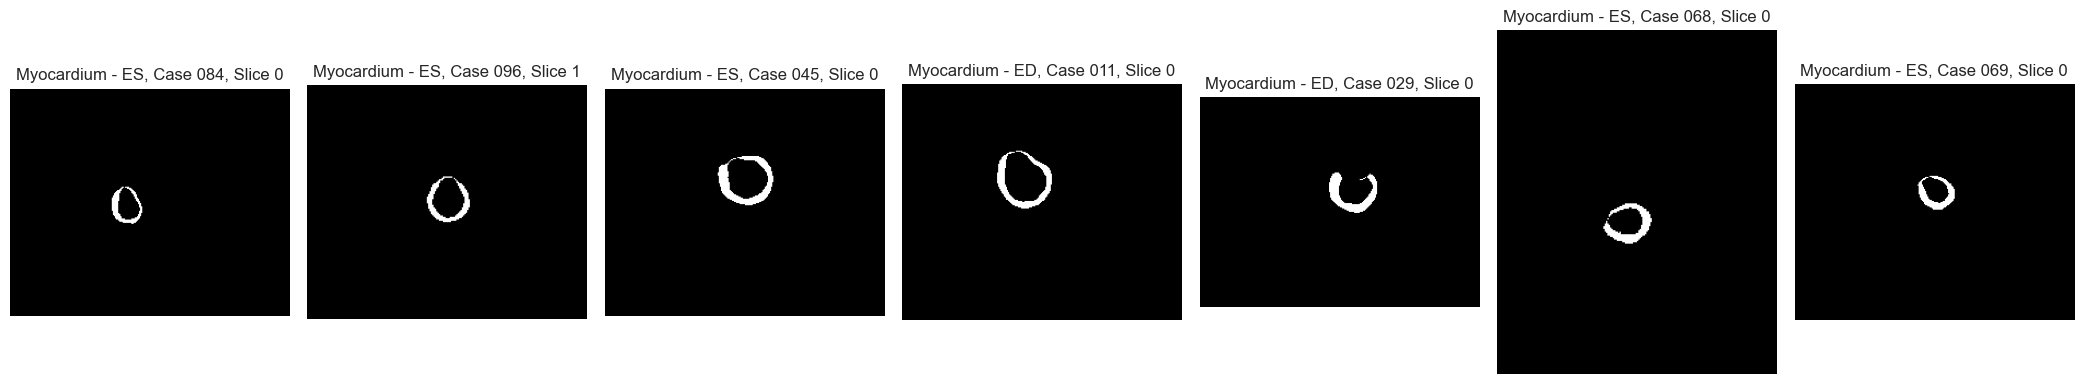

In [28]:
fig, axes = plt.subplots(ncols=len(list_fails), figsize=(3*len(list_fails), 6))

for idx, fail in enumerate(list_fails):

    chosen_data = nifti_train_dict[fail[1]]
    _, _, ed_seg, es_seg = get_volumetric_image(chosen_data)
    
    if fail[0] == 'ES':
        chosen_mask = es_seg[:, :, fail[2]]
    elif fail[0] == 'ED':
        chosen_mask = ed_seg[:, :, fail[2]]

    myo_mask = (chosen_mask == 2)

    # Plot using the corresponding subplot axis
    ax = axes[idx] if len(list_fails) > 1 else axes  # handle single-image edge case
    ax.imshow(myo_mask, cmap='gray')
    ax.set_title(f"Myocardium - {fail[0]}, Case {fail[1]}, Slice {fail[2]}")
    ax.axis('off')

plt.tight_layout()
plt.show() 

All the failure cases shown above exhibit **non-closed myocardium structures**, which prevents the use of the $\texttt{binary\_fill\_holes}$ function to correctly segment the left ventricle (LV). The function relies on completely enclosed regions to identify and fill internal areas, so gaps in the myocardial contour break this logic.

To solve this, we apply a **convex hull** to the myocardium mask to **morphologically close the gaps**. Subtracting the original mask from its convex hull creates a candidate LV region. Then, we extract the **largest connected component** to isolate the **main LV area** and eliminate noise.

#### Closing the gaps

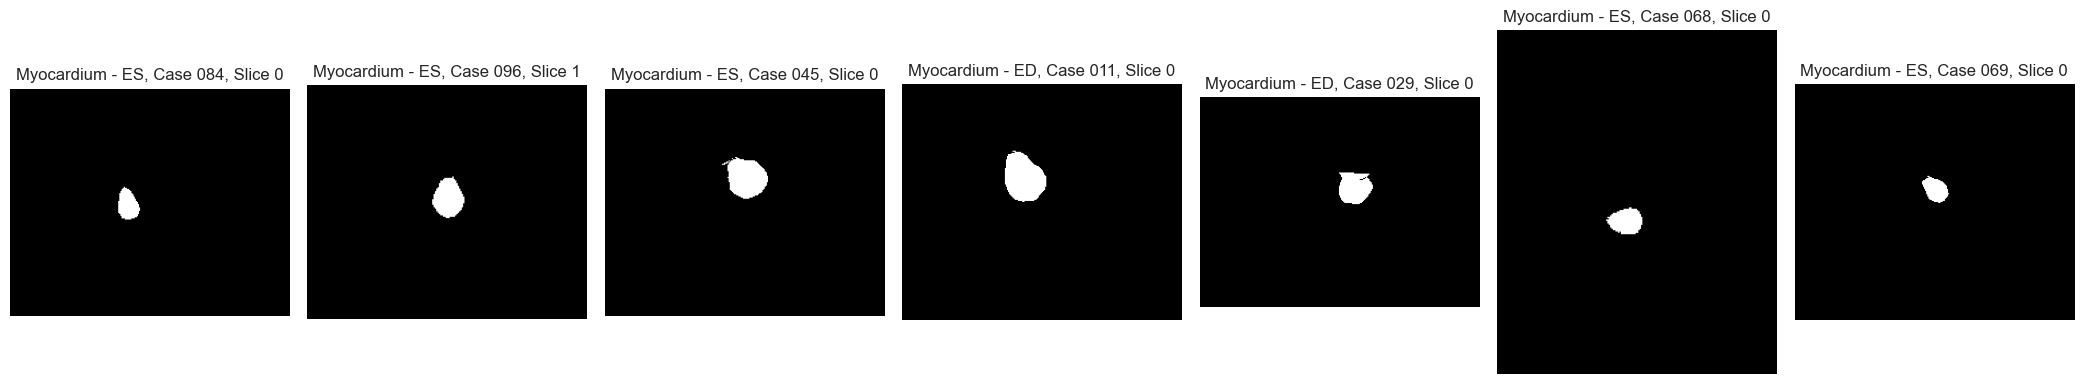

In [29]:
if len(list_fails) == 0:
    print("No failure cases to plot.")
else:
    fig, axes = plt.subplots(ncols=len(list_fails), figsize=(3*len(list_fails), 6))
    
    for idx, fail in enumerate(list_fails):
        chosen_data = nifti_train_dict[fail[1]]
        _, _, ed_seg, es_seg = get_volumetric_image(chosen_data)
        
        # Select the appropriate segmentation slice for ED or ES
        if fail[0] == 'ES':
            chosen_mask = es_seg[:, :, fail[2]]
        elif fail[0] == 'ED':
            chosen_mask = ed_seg[:, :, fail[2]]
    
        myo_mask = (chosen_mask == 2)
    
        # Apply morphological closing and then fill holes (using convex_hull_image)
        convex_myo = convex_hull_image(myo_mask)
        new_lv_area = convex_myo & ~myo_mask
        
        # Keep only the largest connected component in new_lv_area
        labeled_area = label(new_lv_area)
        
        if labeled_area.max() > 0:
            # There is at least one connected component
            regions = regionprops(labeled_area)
            largest_region = max(regions, key=lambda r: r.area)
            largest_mask = (labeled_area == largest_region.label)
        else:
            # No connected components found; fallback is just new_lv_area
            largest_mask = new_lv_area
        
        # Plot using the corresponding subplot axis
        ax = axes[idx] if len(list_fails) > 1 else axes  # handle single-image edge case
        ax.imshow(largest_mask, cmap='gray')
        ax.set_title(f"Myocardium - {fail[0]}, Case {fail[1]}, Slice {fail[2]}")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

The result indicates that the proposed solution successfully closes gaps in the myocardium and fills the left ventricle region. At first, the myocardium contour was incomplete, preventing proper filling. After applying the convex hull and selecting the largest connected component, the myocardium appears fully enclosed, allowing a clear and consistent LV segmentation.

To further validate these results, we will reapply the proposed method to the entire training dataset. We will then evaluate the LV segmentation by identifying slices with an IoU below the 0.9 threshold and calculating the overall mean IoU score across all slices.

### Solution's IoU Score

For evaluating the solution’s IoU score, I added conditional checks to ensure that the metric is computed only for valid cases, specifically, slices that originally contain both LV segmentation and myocardium in the training data. This way, we focus on the cases where the solution is truly applicable.

In [59]:
overall_imperfect = {} 
list_fails = []
all_iou_scores = []

threshold = 0.9

for index in list_keys_train:
    subject_data = nifti_train_dict[index]
    _, _, ed_seg, es_seg = get_volumetric_image(subject_data)
    
    pred_ed_seg = solution_lv_inside_myo(ed_seg, myo_label=2, lv_label=3)
    pred_es_seg = solution_lv_inside_myo(es_seg, myo_label=2, lv_label=3)
    
    num_slices = ed_seg.shape[-1]
    subject_imperfect = {"ED": [], "ES": []}

    for z in range(num_slices):
        gt_has_lv_ed = np.any(ed_seg[..., z] == 3)
        gt_has_lv_es = np.any(es_seg[..., z] == 3)
        gt_has_myo_ed = np.any(ed_seg[..., z] == 2)
        gt_has_myo_es = np.any(es_seg[..., z] == 2)
        
        if (gt_has_lv_ed and gt_has_myo_ed):
        
            iou_lv_ed = compute_iou(pred_ed_seg[..., z], ed_seg[..., z], label=3)
            all_iou_scores.append(iou_lv_ed)
            
            if iou_lv_ed < threshold:
                subject_imperfect["ED"].append((z, iou_lv_ed))
                list_fails.append(['ED', index, z])

        if (gt_has_lv_es and gt_has_myo_es):
            
            iou_lv_es = compute_iou(pred_es_seg[..., z], es_seg[..., z], label=3)
            all_iou_scores.append(iou_lv_es)

            if iou_lv_es < threshold:
                subject_imperfect["ES"].append((z, iou_lv_es))
                list_fails.append(['ES', index, z])
    
    # Only add subject if there is any imperfect slice
    if subject_imperfect["ED"] or subject_imperfect["ES"]:
        overall_imperfect[index] = subject_imperfect

# Print overall result
if not overall_imperfect:
    print("All slices have a perfect match (IoU = 1.000) for all the Train subjects.")
else:
    for index, details in overall_imperfect.items():
        print(f"\nSubject {index} results:")
        for phase in ["ED", "ES"]:
            for z, iou in details[phase]:
                print(f"  {phase} Slice {z}: IoU = {iou:.3f}")

# Compute and print the mean IoU
if all_iou_scores:
    mean_iou = np.mean(all_iou_scores)
    print(f"\nMean IoU across evaluated slices: {mean_iou:.4f}")
else:
    print("\nNo slices were evaluated for IoU calculation.")


Subject 029 results:
  ED Slice 0: IoU = 0.800

Mean IoU across evaluated slices: 0.9998


---
The results are very promising, indicating that the proposed method is highly effective in segmenting the LV region in the training data. Based on these results, I’ll now apply this approach to the test data to segment the missing LVs.

### LV Segmentation

In [56]:
for index in list_keys_test:
    subject_data_test = nifti_test_dict[index]
    _, _, ed_seg_test, es_seg_test = get_volumetric_image(subject_data_test)
    
    # Create new segmentation arrays
    ed_seg_test_new = solution_lv_inside_myo(ed_seg_test, myo_label=2, lv_label=3)
    es_seg_test_new = solution_lv_inside_myo(es_seg_test, myo_label=2, lv_label=3)
    
    # Wrap the new arrays into nibabel Nifti1Image objects using the original affine and header
    subject_data_test['ED_seg'] = nib.Nifti1Image(
        ed_seg_test_new, 
        subject_data_test['ED_seg'].affine, 
        subject_data_test['ED_seg'].header
    )
    subject_data_test['ES_seg'] = nib.Nifti1Image(
        es_seg_test_new, 
        subject_data_test['ES_seg'].affine, 
        subject_data_test['ES_seg'].header
    )

#### Filled LV example

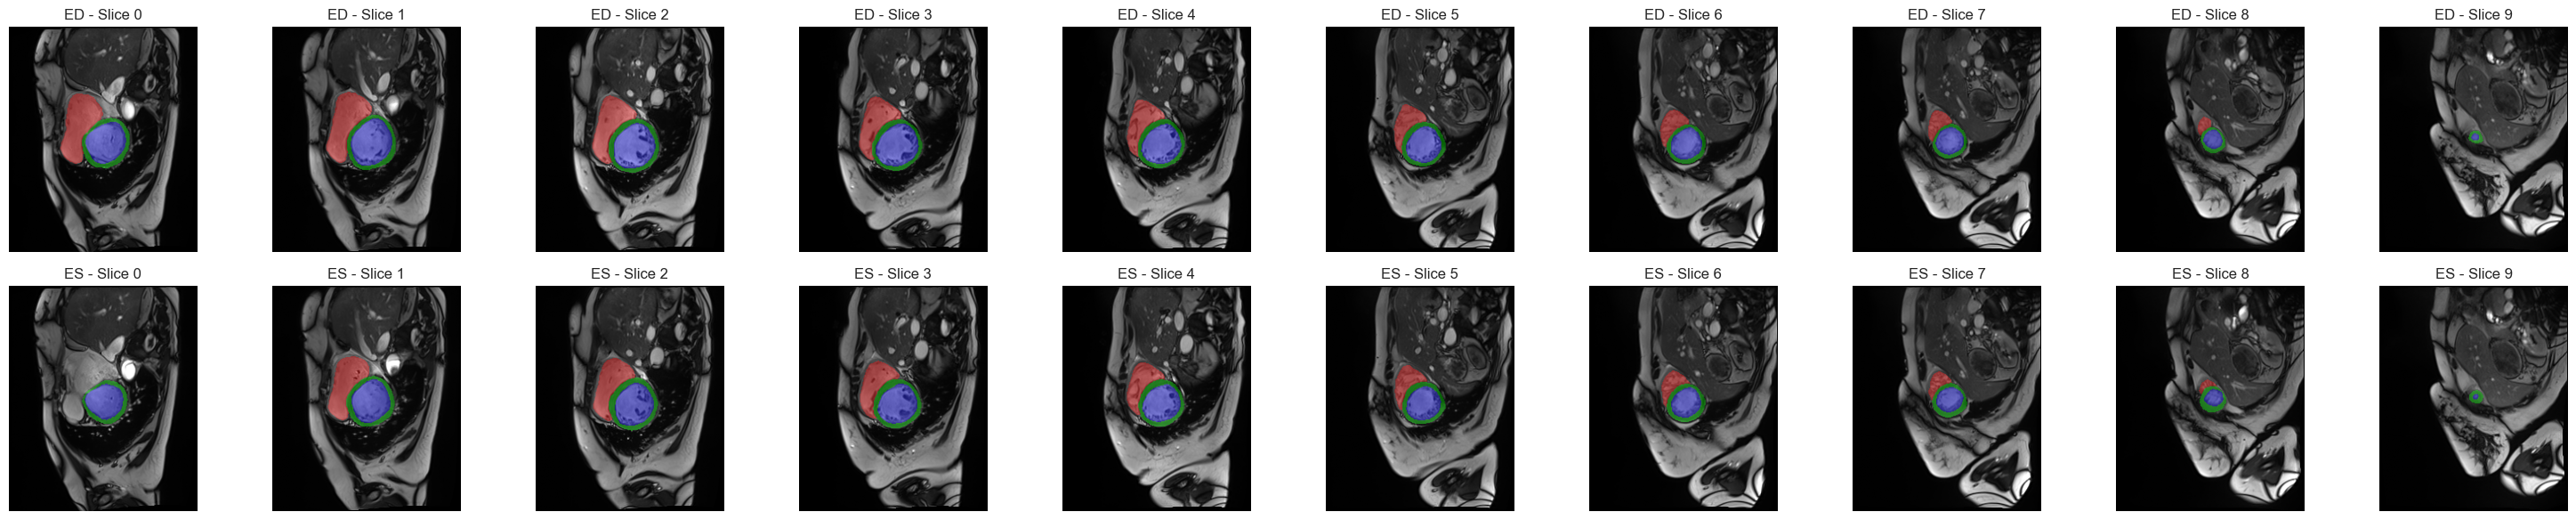

In [57]:
subject_data = nifti_test_dict[random_index]
ed_img, es_img, ed_seg, es_seg = get_volumetric_image(subject_data)

n_slices = ed_img.shape[-1]
fig, axes = plt.subplots(nrows=2, ncols=n_slices, figsize=(3*n_slices, 6))

for i in range(n_slices):
    # ED 
    axes[0, i].imshow(ed_img[:, :, i], cmap='gray', alpha=1.0)
    axes[0, i].imshow(ed_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[0, i].set_title(f"ED - Slice {i}")
    axes[0, i].axis('off')

    # ES 
    axes[1, i].imshow(es_img[:, :, i], cmap='gray', alpha=1.0)
    axes[1, i].imshow(es_seg[:, :, i], cmap=label_cmap, vmin=0, vmax=3, alpha=0.6)
    axes[1, i].set_title(f"ES - Slice {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 5. Metrics and Features <a name="metrics-and-features"></a>

Some of the proposed features by the references are:
* Ejection Fractions (EF)
* Stroke Volumes (SV)
* Left ventricle mass
* Myocardium thickness

This requires accurate delineation of the left ventricular endocardium and epicardium, and of the right ventricular endocardium for both end diastolic (ED) and end systolic (ES) phase instances.

## Volume

Volume of the anatomical structures at two different time points. Explain the volume metric (equation), which volumes it's gonna be used

## Thickness of the Cardiac Muscle


## Ejection Fraction

# 6. Model <a name="model"></a>

## Classification

# 7. Conclusion <a name="conclusion"></a>
